In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("my_data.csv")

In [3]:
print(df)

           name     city  gender profession   age  cgpa  placed
0     moriarity      NaN  female        phd  28.0  5.94       1
1     moriarity   asgard     NaN   bachelor  50.0  8.55       0
2        holmes      NaN  female    masters  18.0  5.56       0
3           sam      NaN    male   bachelor  25.0  8.57       1
4           sam      NaN    male   bachelor  19.0  8.76       1
...         ...      ...     ...        ...   ...   ...     ...
1095     holmes      NaN    male    masters  26.0  8.92       1
1096  moriarity  wakanda    male    masters  19.0  9.01       0
1097        sam   asgard    male   bachelor  30.0  7.88       0
1098       dean   gotham    male    masters  28.0   NaN       1
1099        sam   asgard     NaN    masters  24.0  8.94       1

[1100 rows x 7 columns]


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        1009 non-null   object 
 1   city        905 non-null    object 
 2   gender      994 non-null    object 
 3   profession  921 non-null    object 
 4   age         982 non-null    float64
 5   cgpa        962 non-null    float64
 6   placed      1100 non-null   int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 60.3+ KB


In [5]:
df.isnull().sum()

name           91
city          195
gender        106
profession    179
age           118
cgpa          138
placed          0
dtype: int64

In [6]:
# 1. Drop useless column
df.drop('name', axis=1, inplace=True)

# 2. Fill numerical columns
df['age'] = df['age'].fillna(df['age'].mean())
df['cgpa'] = df['cgpa'].fillna(df['cgpa'].mean())

# 3. Fill categorical columns
df['city'] = df['city'].fillna(df['city'].mode()[0])
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['profession'] = df['profession'].fillna(df['profession'].mode()[0])

In [13]:
df.isnull().sum()


city          0
gender        0
profession    0
age           0
cgpa          0
placed        0
dtype: int64

In [14]:
df.isnull().sum()

city          0
gender        0
profession    0
age           0
cgpa          0
placed        0
dtype: int64

In [15]:
# drop duplicates
df.drop_duplicates(inplace = True)

# change data type of cgpa column
df['cgpa'] = df['cgpa'].astype(int)

In [16]:
print(df['gender'].unique())
print(df['profession'].unique())

[0 1]
['phd' 'bachelor' 'masters']


In [17]:
# feature Engineering 
# 1 = male
# 2 = female
df['gender'] = df['gender'].map({'male': 1, 'female': 0})

# phd = 1, bachelor = 2 , master = 3
df['profession'] = df['profession'].map({'phd':1, 'bachelor':2, 'master':3})



In [18]:
df

,city,gender,profession,age,cgpa,placed
0,wakanda,NaN,1.0,28.000000,5,1
1,asgard,NaN,2.0,50.000000,8,0
2,wakanda,NaN,NaN,18.000000,5,0
3,wakanda,NaN,2.0,25.000000,8,1
4,wakanda,NaN,2.0,19.000000,8,1
...,...,...,...,...,...,...
1072,wakanda,NaN,1.0,28.429735,8,1
1073,gotham,NaN,2.0,24.000000,8,1
1080,gotham,NaN,2.0,26.000000,7,1
1090,asgard,NaN,2.0,28.000000,9,0


In [20]:
# check duplicates
print(df.duplicated().sum())

82


In [21]:
df.drop_duplicates(inplace = True)

In [22]:
print(df.duplicated().sum())

0


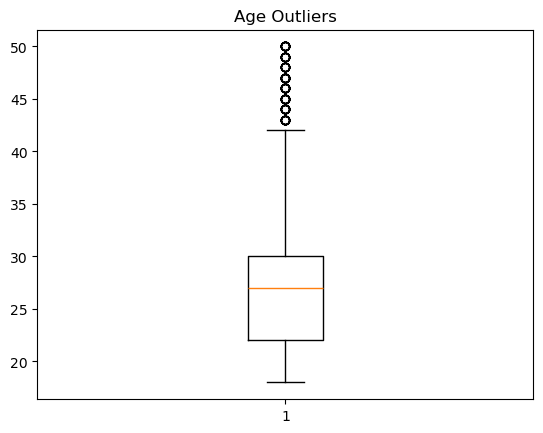

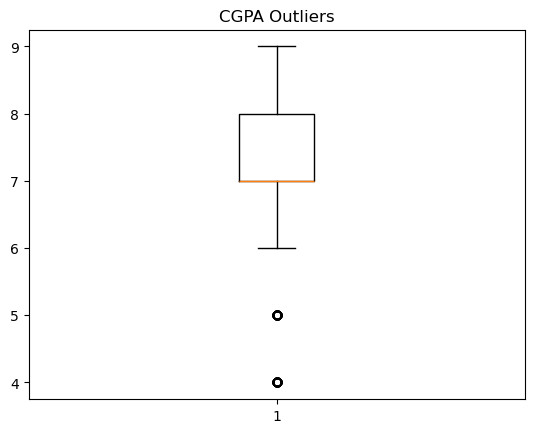

In [23]:
# check outliers

plt.boxplot(df['age'])
plt.title("Age Outliers")
plt.show()

plt.boxplot(df['cgpa'])
plt.title("CGPA Outliers")
plt.show()

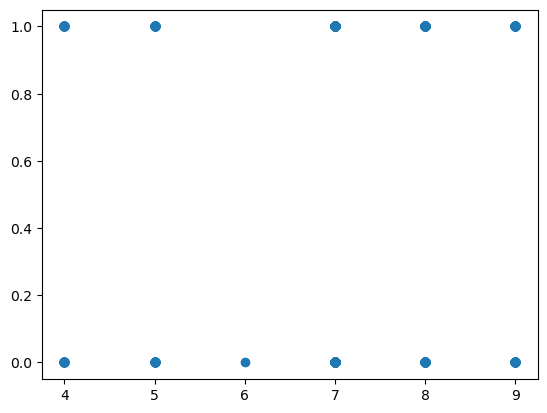

In [25]:
# visualization 
# cgpa vs placement 
plt.scatter(df['cgpa'], df['placed'])

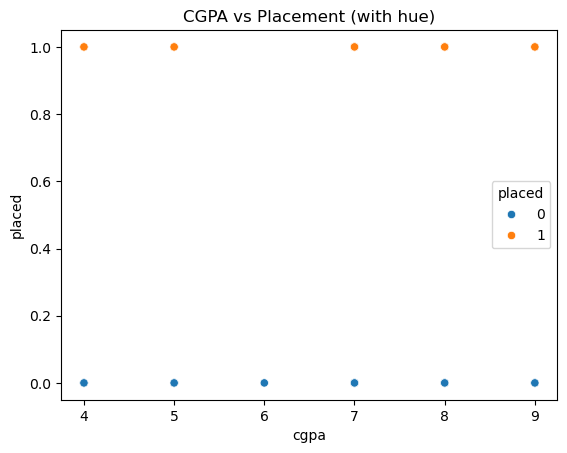

In [28]:
sns.scatterplot(x='cgpa', y='placed', hue='placed', data=df)
plt.title("CGPA vs Placement (with hue)")
plt.show()

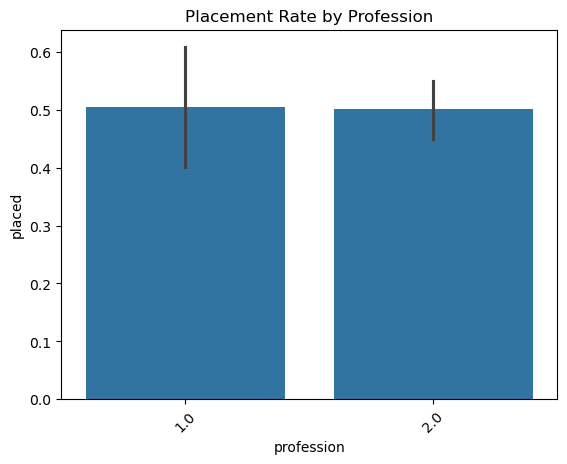

In [30]:
sns.barplot(x='profession', y='placed', data=df)
plt.xticks(rotation=45)
plt.title("Placement Rate by Profession")
plt.show()

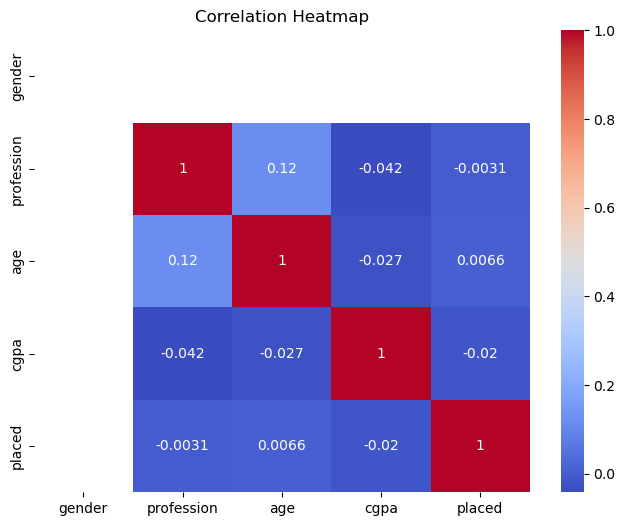

In [31]:
numeric_df = df.select_dtypes(include=['number'])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()